# Lab 8 (Week 2 — Lab 3): Classification Models

**Name:** Numair Fahad

**Role:** AI/ML Intern

**Company:** Zynvex Solutions

**GitHub:** https://github.com/numair-2003/AIML-Internship-NumairFahad

Welcome to Lab 8! In this lab you will build classification models that predict a category instead of a number. You'll practice Logistic Regression, K-Nearest Neighbors, and Decision Trees using the Iris dataset.

**For detailed theory on how each algorithm works, see the Lab 8 PDF and Learning Resources.**

This notebook focuses on the practical, hands-on workflow.

**Instructions:**
- Write your code between the `### YOUR CODE HERE ###` and `### END ###` markers.
- Run each cell with **Shift + Enter**.
- Compare your output with the **Expected Output** shown below each exercise where provided.

## Getting the Dataset

This lab uses the Iris dataset, which is built directly into scikit-learn — no download or upload needed.

In [1]:
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target_names[iris.target]

print(df.shape)
df.head()

(150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [2]:
from sklearn.model_selection import train_test_split

X = df[iris.feature_names]
y = iris.target   # numeric labels: 0, 1, 2

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

Training set size: 120
Test set size: 30


## Example 1: Logistic Regression

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_model = LogisticRegression(max_iter=200)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))

Logistic Regression Accuracy: 1.0


## Example 2: K-Nearest Neighbors (KNN)

In [4]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 1.0


## Example 3: Decision Tree

In [5]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))

Decision Tree Accuracy: 1.0


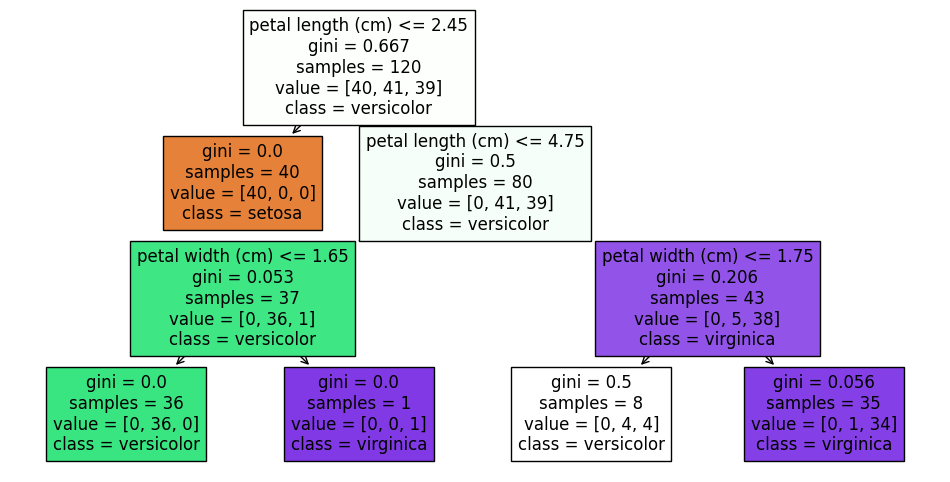

In [6]:
plt.figure(figsize=(12, 6))
plot_tree(tree_model, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()

## Practice Exercise 1: KNN with a Different k

**Exercise:** Train a KNN model with `n_neighbors=3` instead of 5. Compare its accuracy to the k=5 version from Example 2.

In [7]:
### YOUR CODE HERE ###
knn_model_3 = KNeighborsClassifier(n_neighbors=3)
knn_model_3.fit(X_train, y_train)

y_pred_knn3 = knn_model_3.predict(X_test)
accuracy_knn3 = accuracy_score(y_test, y_pred_knn3)
### END ###

print("KNN (k=3) Accuracy: ", accuracy_knn3)
print("KNN (k=5) Accuracy: ", accuracy_score(y_test, y_pred_knn))

KNN (k=3) Accuracy:  1.0
KNN (k=5) Accuracy:  1.0


## Practice Exercise 2: Decision Tree Depth Comparison

**Exercise:** Train a Decision Tree with `max_depth=1` (a very shallow tree) and compare its accuracy to the `max_depth=3` version from Example 3. What do you notice?

In [8]:
### YOUR CODE HERE ###
tree_model_1 = DecisionTreeClassifier(max_depth=1, random_state=42)
tree_model_1.fit(X_train, y_train)

y_pred_tree1 = tree_model_1.predict(X_test)
accuracy_tree1 = accuracy_score(y_test, y_pred_tree1)

print("Decision Tree (max_depth=1) Accuracy: ", accuracy_tree1)
print("Decision Tree (max_depth=3) Accuracy: ", accuracy_score(y_test, y_pred_tree))
### END ###

Decision Tree (max_depth=1) Accuracy:  0.6333333333333333
Decision Tree (max_depth=3) Accuracy:  1.0


### Observation about shallow vs deeper decision trees

The **shallow Decision Tree** with **max_depth=1** achieved only **63.3%** accuracy, while the **deeper tree** with **max_depth=3** achieved **100%** accuracy. This shows that a very shallow tree underfits the data since it is too simple and cannot capture and learn the patterns properly. A slightly deeper tree performs much better on this dataset.

## Practice Exercise 3: Predicting a New Sample

**Exercise:** Create a new, single flower measurement (choose any reasonable values for the 4 features) and use your trained Logistic Regression model to predict its species.

In [9]:
### YOUR CODE HERE ###
new_sample = pd.DataFrame([[5.1, 3.6, 1.5, 0.2]], columns=iris.feature_names) # should be a 2D array/list with one row of 4 measurements
predicted_species = log_model.predict(new_sample)
### END ###

print("Predicted species: ", iris.target_names[predicted_species[0]])

Predicted species:  setosa


## Lab Tasks

Complete the following in this notebook, below this cell.

1. **Train All Three Models**: Train Logistic Regression, KNN (k=5), and a Decision Tree (max_depth=3) on the Iris dataset, and print the accuracy of each.
2. **Model Comparison Table**: Create a small summary (a Pandas DataFrame or printed table) comparing the accuracy of all three models side by side.
3. **Hyperparameter Exploration**: Try at least 3 different values of `n_neighbors` for KNN (e.g., 1, 5, 10) and report which gives the best accuracy.
4. **Visualize the Tree**: Plot your Decision Tree model using `plot_tree()`, and in a markdown cell, describe in your own words what the first split (the root of the tree) is checking.
5. **Reflection**: In a markdown cell, write 3-4 sentences on which model performed best on this dataset, and one reason you think that might be the case.

In [10]:
# Task 1
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

log_model_2 = LogisticRegression(max_iter=200)
log_model_2.fit(X_train, y_train)

y_pred_log2 = log_model_2.predict(X_test)
accuracy_log2 = accuracy_score(y_test, y_pred_log2)

model_knn5 = KNeighborsClassifier(n_neighbors=5)
model_knn5.fit(X_train, y_train)

y_pred_knn5 = model_knn5.predict(X_test)
accuracy_knn5 = accuracy_score(y_test, y_pred_knn5)

tree_model_3 = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model_3.fit(X_train, y_train)

y_pred_tree3 = tree_model_3.predict(X_test)
accuracy_tree3 = accuracy_score(y_test, y_pred_tree3)

print("Logistic Regression accuracy score: ", accuracy_log2)
print("KNN (k=5) accuracy score: ", accuracy_knn5)
print("Decision Tree (max_depth=3) accuracy score: ", accuracy_tree3)


Logistic Regression accuracy score:  1.0
KNN (k=5) accuracy score:  1.0
Decision Tree (max_depth=3) accuracy score:  1.0


In [14]:
# Task 2
import pandas as pd

compare_accuracies = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN (k=5)', 'Decision Tree (max_depth=3)'],
    'Accuracy_Score': [accuracy_log2, accuracy_knn5, accuracy_tree3]
})

print(compare_accuracies)


                         Model  Accuracy_Score
0          Logistic Regression             1.0
1                    KNN (k=5)             1.0
2  Decision Tree (max_depth=3)             1.0


In [15]:
# Task 3
for k in [1, 5, 10]:
  model_knn_k = KNeighborsClassifier(n_neighbors=k)
  model_knn_k.fit(X_train, y_train)

  y_pred_knnk = model_knn_k.predict(X_test)
  accuracy_knnk = accuracy_score(y_test, y_pred_knnk)

  print(f"KNN {k} accuracy score: {accuracy_knnk}")

KNN 1 accuracy score: 1.0
KNN 5 accuracy score: 1.0
KNN 10 accuracy score: 1.0


### Which KNN model gives the best accuracy?

All KNN models (with n_neighbors = 1, 5 and 10) achieved the best accuracy of 1.0 on the Iris dataset, which is normal for this dataset.

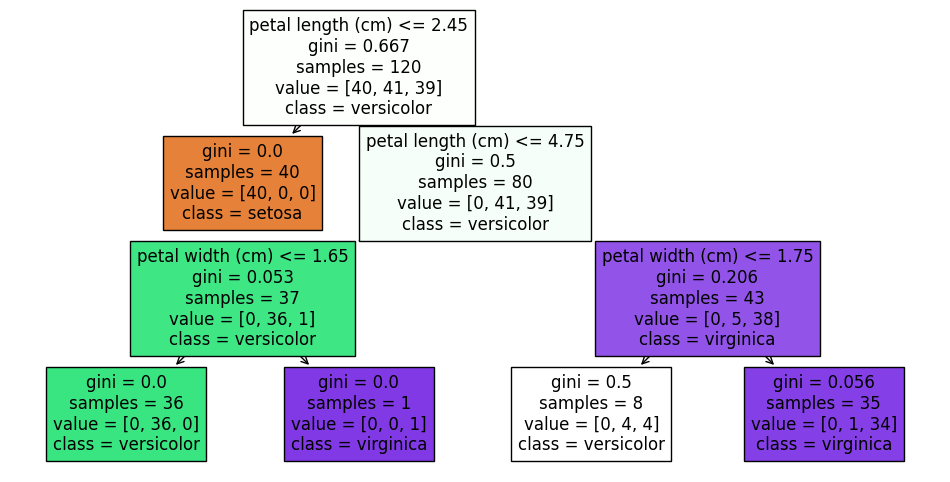

In [16]:
# Task 4
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plot_tree(tree_model, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)

plt.show()

### What is the first split (the root of the tree) checking?

The first split (root of the tree) is checking:

“Is the petal length ≤ 2.45 cm?”

* If Yes, then the flower is classified as setosa.

* If No, the tree continues to expand to the other splits.


# Task 5

All three classification models (**Logistic Regression**, **KNN**, and **Decision Tree**) performed equally well on the provided Iris dataset, each achieving an **accuracy score** of **100%** (**1.0**). This is because the Iris dataset is small, clean, and so, the three species are easily separable based on petal measurements.

Among them, the **Decision Tree** is considered extremely useful since it is easy and simple to interpret and visualize, allowing us to clearly observe and analyze which features (especially **petal length**) are most significant for classification.

In [18]:
from google.colab import drive
drive.mount('/content/drive')

!git clone https://github.com/numair-2003/AIML-Internship-NumairFahad.git

Mounted at /content/drive
Cloning into 'AIML-Internship-NumairFahad'...
remote: Enumerating objects: 60, done.
remote: Counting objects: 100% (60/60), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 60 (delta 25), reused 23 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (60/60), 852.27 KiB | 17.39 MiB/s, done.
Resolving deltas: 100% (25/25), done.


In [ ]:
!cp "/content/drive/MyDrive/Colab Notebooks/Lab 08_NumairFahad.ipynb" "/content/your-repo/"